# Evaluating the Educational Impact of a Large Language Model (LLM)Based Virtual Assistant in Video-Based Learning Figures

---

In [171]:
import os, sys
import polars as pl

script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..', '..')

data_filename = 'processed_forms_interactions_data.parquet'
data_path = os.path.join(project_path, 'data', 'combined', data_filename)

sys.path.append(project_path)
from src.utils.educational_impact.educational_impact_analysis import (
    group_stats,
    plot_cat_distribution,
    plot_cat_comparison,
    plot_quant_distribution,
    plot_quant_comparison,
    plot_quant_comparison_faceted,
    plot_quant_scatter,
    plot_quant_pie
)

forms_interactions_df = pl.read_parquet(data_path)


---

## Vista de la tabla

---

## Detección de inconsistencias

### Grupo Control/Experimental vs Métricas Herramienta

In [172]:
forms_interactions_df['grupo'].value_counts()

grupo,count
str,u32
"""control""",97
"""experimental""",94


In [173]:
forms_interactions_df['chat_freq_use'].value_counts()

chat_freq_use,count
str,u32
"""Baja""",9
"""Media""",24
null,100
"""Alta""",29
"""No Usado""",29


In [174]:
forms_interactions_df['chat_freq_use'].value_counts().filter(pl.col('chat_freq_use').is_null())['count'][0]

100

In [175]:
forms_interactions_df['grupo'].value_counts().filter(pl.col('grupo') == 'control')['count'][0]

97

Todos los de control tienen null en la herramienta? --> Si --> No problema



In [176]:
forms_interactions_df.filter(
    pl.col('grupo') == 'control',
    pl.col('chat_freq_use').is_not_null()
)

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_hake_gain_cat,puntuacion_tc_retencion_hake_gain_cat,puntuacion_tc_transferencia_hake_gain_cat,puntuacion_tc_units_hake_gain,puntuacion_tc_retencion_units_hake_gain,puntuacion_tc_transferencia_units_hake_gain,puntuacion_tc_units_hake_gain_cat,puntuacion_tc_retencion_units_hake_gain_cat,puntuacion_tc_transferencia_units_hake_gain_cat,puntuacion_ta_hake_gain,puntuacion_ta_hake_gain_cat,puntuacion_ta_units_hake_gain,mejora_hake_gain,mejora_hake_gain_v2,mejora_units_hake_gain,niveles_mejora_hake_gain,niveles_mejora_hake_gain_v2,puntuacion_tc_cat_trad_scale_pre,puntuacion_tc_cat_trad_scale_v2_pre,puntuacion_tc_retencion_cat_trad_scale_v2_pre,puntuacion_tc_transferencia_cat_trad_scale_v2_pre,puntuacion_tc_cat_trad_scale_post,puntuacion_tc_cat_trad_scale_v2_post,puntuacion_tc_retencion_cat_trad_scale_v2_post,puntuacion_tc_transferencia_cat_trad_scale_v2_post,marca temporal_pre,marca temporal_post,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,…,chat_freq_use,chat_freq_use_v2,WSDI,count_cheating,count_out_of_context,count_superficial,count_deep,WSDI_cat,WSDI_cat_v2,high_quality_use,cheating_score_llm,count_retention,count_transference,experimental_type_v1,experimental_type_v2,experimental_type_v3,experimental_type_v4,experimental_type_v5,experimental_type_v6,grupo_segmented_v1,grupo_segmented_v2,grupo_segmented_v3,grupo_segmented_v4,grupo_segmented_v5,grupo_segmented_v6,pre_post_time_interval,nombre,direccion,curso,lat,lon,seccion_censal,municipio,provincia,mediana_renta_uc_eur,renta_media_hogar_eur,renta_media_persona_eur
str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,str,str,str,f64,str,f64,bool,str,bool,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,…,str,str,f64,u32,u32,u32,u32,str,str,str,f64,u32,u32,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,f64,f64,i64,str,str,i64,i64,i64


Hay alguno de experimental con null en la herramienta? --> Si --> Problema

In [177]:
forms_interactions_df.filter(
    pl.col('grupo') == 'experimental',
    pl.col('chat_freq_use').is_null()
)

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_hake_gain_cat,puntuacion_tc_retencion_hake_gain_cat,puntuacion_tc_transferencia_hake_gain_cat,puntuacion_tc_units_hake_gain,puntuacion_tc_retencion_units_hake_gain,puntuacion_tc_transferencia_units_hake_gain,puntuacion_tc_units_hake_gain_cat,puntuacion_tc_retencion_units_hake_gain_cat,puntuacion_tc_transferencia_units_hake_gain_cat,puntuacion_ta_hake_gain,puntuacion_ta_hake_gain_cat,puntuacion_ta_units_hake_gain,mejora_hake_gain,mejora_hake_gain_v2,mejora_units_hake_gain,niveles_mejora_hake_gain,niveles_mejora_hake_gain_v2,puntuacion_tc_cat_trad_scale_pre,puntuacion_tc_cat_trad_scale_v2_pre,puntuacion_tc_retencion_cat_trad_scale_v2_pre,puntuacion_tc_transferencia_cat_trad_scale_v2_pre,puntuacion_tc_cat_trad_scale_post,puntuacion_tc_cat_trad_scale_v2_post,puntuacion_tc_retencion_cat_trad_scale_v2_post,puntuacion_tc_transferencia_cat_trad_scale_v2_post,marca temporal_pre,marca temporal_post,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,…,chat_freq_use,chat_freq_use_v2,WSDI,count_cheating,count_out_of_context,count_superficial,count_deep,WSDI_cat,WSDI_cat_v2,high_quality_use,cheating_score_llm,count_retention,count_transference,experimental_type_v1,experimental_type_v2,experimental_type_v3,experimental_type_v4,experimental_type_v5,experimental_type_v6,grupo_segmented_v1,grupo_segmented_v2,grupo_segmented_v3,grupo_segmented_v4,grupo_segmented_v5,grupo_segmented_v6,pre_post_time_interval,nombre,direccion,curso,lat,lon,seccion_censal,municipio,provincia,mediana_renta_uc_eur,renta_media_hogar_eur,renta_media_persona_eur
str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,str,str,str,f64,str,f64,bool,str,bool,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,…,str,str,f64,u32,u32,u32,u32,str,str,str,f64,u32,u32,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,f64,f64,i64,str,str,i64,i64,i64
"""JesusMaria-nre""","""JesusMaria""","""experimental""",-1.0,0.0,0.0,"""Baja""","""Baja""","""Baja""",-0.1,0.0,0.0,"""Baja""","""Baja""","""Baja""",0.236,"""Alta""",0.17,false,"""Empeora""",false,"""Empeoramiento-Alto""","""Empeoramiento-Alto""","""sobresaliente""","""notable-sobresaliente""","""notable-sobresaliente""","""notable-sobresaliente""","""notable""","""notable-sobresaliente""","""notable-sobresaliente""","""notable-sobresaliente""","""11/03/2026 9:48:45""","""11/03/2026 10:27:34""",0.9,0.28,0.8,1.0,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,38.816667,"""Colegio Jesús María - García N…","""Calle Hermanos García Noblejas…","""1ºBACHILLERATO""",40.429461,-3.633087,2807915073,"""Madrid""","""Madrid""",15750,34137,11571
"""JesusMaria-3ci""","""JesusMaria""","""experimental""",0.0,-1.0,0.5,"""Baja""","""Baja""","""Media""",0.0,-0.2,0.2,"""Baja""","""Baja""","""Baja""",0.231,"""Media""",0.12,false,"""No Mejora""",false,"""No Mejora""","""No Mejora""","""notable""","""notable-sobresaliente""","""notable-sobresaliente""","""suspenso-suficiente-bien""","""notable""","""notable-sobresaliente""","""suspenso-suficiente-bien""","""notable-sobresaliente""","""11/03/2026 9:50:39""","""11/03/2026 10:30:02""",0.7,0.48,0.8,0.6,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,39.383333,"""Colegio Jesús María - García N…","""Calle Hermanos García Noblejas…","""1ºBACHILLERATO""",40.429461,-3.633087,2807915073,"""Madrid""","""Madrid""",15750,34137,11571
"""JesusMaria-33y""","""JesusMaria""","""experimental""",-1.25,-3.0,-0.667,"""Baja""","""Baja""","""Baja""",-0.5,-0.6,-0.4,"""Baja""","""Baja""","""Baja""",0.055,"""Media""",0.03,false,"""Empeora""",false,"""Empeoramiento-Alto""","""Empeoramiento-Alto""","""bien""","""suspenso-suficiente-bien""","""notable-sobresaliente""","""suspenso-suficiente-bien"""

---

## Descripción general

In [178]:
forms_interactions_df.describe()

statistic,id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_hake_gain_cat,puntuacion_tc_retencion_hake_gain_cat,puntuacion_tc_transferencia_hake_gain_cat,puntuacion_tc_units_hake_gain,puntuacion_tc_retencion_units_hake_gain,puntuacion_tc_transferencia_units_hake_gain,puntuacion_tc_units_hake_gain_cat,puntuacion_tc_retencion_units_hake_gain_cat,puntuacion_tc_transferencia_units_hake_gain_cat,puntuacion_ta_hake_gain,puntuacion_ta_hake_gain_cat,puntuacion_ta_units_hake_gain,mejora_hake_gain,mejora_hake_gain_v2,mejora_units_hake_gain,niveles_mejora_hake_gain,niveles_mejora_hake_gain_v2,puntuacion_tc_cat_trad_scale_pre,puntuacion_tc_cat_trad_scale_v2_pre,puntuacion_tc_retencion_cat_trad_scale_v2_pre,puntuacion_tc_transferencia_cat_trad_scale_v2_pre,puntuacion_tc_cat_trad_scale_post,puntuacion_tc_cat_trad_scale_v2_post,puntuacion_tc_retencion_cat_trad_scale_v2_post,puntuacion_tc_transferencia_cat_trad_scale_v2_post,marca temporal_pre,marca temporal_post,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,…,chat_freq_use,chat_freq_use_v2,WSDI,count_cheating,count_out_of_context,count_superficial,count_deep,WSDI_cat,WSDI_cat_v2,high_quality_use,cheating_score_llm,count_retention,count_transference,experimental_type_v1,experimental_type_v2,experimental_type_v3,experimental_type_v4,experimental_type_v5,experimental_type_v6,grupo_segmented_v1,grupo_segmented_v2,grupo_segmented_v3,grupo_segmented_v4,grupo_segmented_v5,grupo_segmented_v6,pre_post_time_interval,nombre,direccion,curso,lat,lon,seccion_censal,municipio,provincia,mediana_renta_uc_eur,renta_media_hogar_eur,renta_media_persona_eur
str,str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,str,str,str,f64,str,f64,f64,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,…,str,str,f64,f64,f64,f64,f64,str,str,str,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,f64,f64,f64,str,str,f64,f64,f64
"""count""","""191""","""191""","""191""",191.0,191.0,191.0,"""191""","""191""","""191""",191.0,191.0,191.0,"""191""","""191""","""191""",191.0,"""191""",191.0,191.0,"""191""",191.0,"""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""","""191""",191.0,191.0,191.0,…,"""91""","""91""",62.0,62.0,62.0,62.0,62.0,"""91""","""91""","""91""",62.0,51.0,51.0,"""91""","""91""","""91""","""91""","""91""","""91""","""188""","""188""","""188""","""188""","""188""","""188""",191.0,"""163""","""163""","""163""",163.0,163.0,163.0,"""163""","""163""",163.0,163.0,163.0
"""null_count""","""0""","""0""","""0""",0.0,0.0,0.0,"""0""","""0""","""0""",0.0,0.0,0.0,"""0""","""0""","""0""",0.0,"""0""",0.0,0.0,"""0""",0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,…,"""100""","""100""",129.0,129.0,129.0,129.0,129.0,"""100""","""100""","""100""",129.0,140.0,140.0,"""100""","""100""","""100""","""100""","""100""","""100""","""3""","""3""","""3""","""3""","""3""","""3""",0.0,"""28""","""28""","""28""",28.0,28.0,28.0,"""28""","""28""",28.0,28.0,28.0
"""mean""",null,null,null,0.312508,0.209445,0.417984,null,null,null,0.162304,0.125654,0.233508,null,null,null,0.087377,null,0.06534,0.717277,null,0.717277,null,null,null,null,null,null,null,null,null,null,null,null,0.60733,0.438901,0.684817,…,null,null,1.737468,1.306452,0.451613,1.080645,0.854839,null,null,null,0.367665,2.176471,0.176471,null,null,null,null,null,null,null,null,null,null,null,null,32.646248,null,null,null,40.399811,-3.678199,2.8075e9,null,null,26842.638037,59652.404908,21326.760736
"""std""",null,null,null,0.632694,0.839672,0.507239,null,null,null,0.21062,0.271684,0.261429,null,null,null,0.249136,null,0.136639,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.182234,0.128556,0.232447,…,null,null,0.70161,1.409438,1.096603,1.07579,1.099132,null,null,null,0.351898,1.260252,0.47774,null,null,null,null,null

---

## Análisis de resultados


### Definición de variables

In [179]:
quant_cols = [col for col, type in zip(forms_interactions_df.columns, forms_interactions_df.dtypes) if type in [pl.Float64, pl.Int64, pl.UInt32]] 
cat_cols = [col for col in forms_interactions_df.columns if col not in quant_cols]

context_cols = ['centro', 'grupo']

centros_cols = [ 
    'nombre',
    'direccion',
    'curso',
    'lat',
    'lon',
    'seccion_censal',
    'municipio',
    'provincia',
    'mediana_renta_uc_eur',
    'renta_media_hogar_eur',
    'renta_media_persona_eur'
]

time_cols = [col for col in forms_interactions_df.columns if 'temp' in col or 'time' in col]

group_segmented_cols = [ 
    'grupo_segmented_v1',
    'grupo_segmented_v2',
    'grupo_segmented_v3',
    'grupo_segmented_v4',
    'grupo_segmented_v5',
    'grupo_segmented_v6'
]

forms_cols = [col for col in forms_interactions_df.columns if 'puntuacion' in col or 'mejora' in col]
forms_quant_cols = [col for col in forms_cols if col in quant_cols]
forms_cat_cols = [col for col in forms_cols if col in cat_cols]

chats_cols = [col for col in forms_interactions_df.columns if col not in forms_cols + context_cols + centros_cols + time_cols + group_segmented_cols + ['id']]
chats_cat_cols = [col for col in chats_cols if col in cat_cols]
chats_quant_cols = [col for col in chats_cols if col in quant_cols]

### Variables de contexto

### Métricas de Rendimiento Forms

#### TC-Hake

In [180]:
hake_gain_quant_cols = [col for col in forms_quant_cols if 'hake' in col and 'units' not in col and "tc" in col]
units_hake_gain_quant_cols = [col for col in forms_quant_cols if 'hake' in col and 'units' in col and "tc" in col]

hake_gain_cat_cols = [col for col in forms_cat_cols if 'hake' in col and 'units' not in col and 'mejora' not in col and "tc" in col]
units_hake_gain_cat_cols = [col for col in forms_cat_cols if 'hake' in col and 'units' in col and 'mejora' not in col and "tc" in col]

#### TC-Pre-Post

In [181]:
tc_pre_quant_cols = [col for col in forms_quant_cols if 'tc_' in col and 'hake' not in col and 'pre' in col]
tc_pre_cat_cols = [col for col in forms_cat_cols if 'tc_' in col and 'hake' not in col and 'pre' in col and 'trad' not in col]

tc_post_quant_cols = [col for col in forms_quant_cols if 'tc_' in col and 'hake' not in col and 'post' in col]
tc_post_cat_cols = [col for col in forms_cat_cols if 'tc_' in col and 'hake' not in col and 'post' in col and  'trad' not in col] 

#### TC-Pre-Post Mejora

#### TA-Pre-Post

In [182]:
ta_quant_cols = [col for col in forms_quant_cols if 'ta_' in col]
ta_cat_cols = [col for col in forms_cat_cols if 'ta_' in col]

#### TCC-Post

In [183]:
tcc_quant_cols = [col for col in forms_quant_cols if 'tcc_' in col]
tcc_cat_cols = [col for col in forms_cat_cols if 'tcc_' in col]

### Métricas Interacciones Herramienta

### Análisis Cruzado 

#### Filtrado de participantes problematicos

In [184]:
q25 = forms_interactions_df['puntuacion_tc_hake_gain'].quantile(0.25)
q75 = forms_interactions_df['puntuacion_tc_hake_gain'].quantile(0.75)
iqr = q75-q25
outliers_lower_bound = q25 - 1.5*iqr

forms_interactions_df.filter(
    pl.col('puntuacion_tc_hake_gain') < outliers_lower_bound
)['id', 'grupo', 'puntuacion_tc_pre', 'puntuacion_tc_post', 'puntuacion_tc_units_hake_gain', 'puntuacion_tc_hake_gain']

id,grupo,puntuacion_tc_pre,puntuacion_tc_post,puntuacion_tc_units_hake_gain,puntuacion_tc_hake_gain
str,str,f64,f64,f64,f64
"""RamiroMaeztu-86g""","""experimental""",0.8,0.5,-0.3,-1.5
"""RamiroMaeztu-4bc""","""experimental""",0.9,0.6,-0.3,-3.0
"""JesusMaria-ub4""","""control""",0.9,0.7,-0.2,-2.0
"""JesusMaria-yxb""","""control""",0.9,0.7,-0.2,-2.0
"""JesusMaria-33y""","""experimental""",0.6,0.1,-0.5,-1.25
"""Laguna-chk""","""experimental""",0.9,0.6,-0.3,-3.0


In [185]:
q25 = forms_interactions_df['puntuacion_tc_units_hake_gain'].quantile(0.25)
q75 = forms_interactions_df['puntuacion_tc_units_hake_gain'].quantile(0.75)
iqr = q75-q25
outliers_lower_bound = q25 - 1.5*iqr

forms_interactions_df.filter(
    pl.col('puntuacion_tc_units_hake_gain') < outliers_lower_bound
)['id', 'grupo', 'puntuacion_tc_pre', 'puntuacion_tc_post', 'puntuacion_tc_units_hake_gain', 'puntuacion_tc_hake_gain']

id,grupo,puntuacion_tc_pre,puntuacion_tc_post,puntuacion_tc_units_hake_gain,puntuacion_tc_hake_gain
str,str,f64,f64,f64,f64
"""JesusMaria-33y""","""experimental""",0.6,0.1,-0.5,-1.25


In [186]:
forms_interactions_df.filter(
    pl.col('puntuacion_tc_pre') == 1
)['id', 'grupo', 'puntuacion_tc_pre', 'puntuacion_tc_post', 'puntuacion_tc_units_hake_gain', 'puntuacion_tc_hake_gain']

id,grupo,puntuacion_tc_pre,puntuacion_tc_post,puntuacion_tc_units_hake_gain,puntuacion_tc_hake_gain
str,str,f64,f64,f64,f64
"""JoseGarciaNieto-lp9""","""control""",1.0,0.9,0.0,0.0
"""JesusMaria-86o""","""control""",1.0,1.0,0.0,0.0
"""Laguna-o61""","""experimental""",1.0,0.5,0.0,0.0
"""Laguna-yno""","""experimental""",1.0,0.8,0.0,0.0
"""Laguna-9wq""","""experimental""",1.0,0.9,0.0,0.0


In [187]:
forms_interactions_df.filter(
    pl.col('grupo') == 'experimental',
    pl.col('chat_freq_use').is_null()
)['id', 'grupo', 'puntuacion_tc_pre', 'puntuacion_tc_post', 'puntuacion_tc_units_hake_gain', 'puntuacion_tc_hake_gain', 'chat_freq_use']

id,grupo,puntuacion_tc_pre,puntuacion_tc_post,puntuacion_tc_units_hake_gain,puntuacion_tc_hake_gain,chat_freq_use
str,str,f64,f64,f64,f64,str
"""JesusMaria-nre""","""experimental""",0.9,0.8,-0.1,-1.0,null
"""JesusMaria-3ci""","""experimental""",0.7,0.7,0.0,0.0,null
"""JesusMaria-33y""","""experimental""",0.6,0.1,-0.5,-1.25,null


In [188]:
problematic_ids = forms_interactions_df.filter(
    pl.col('grupo') == 'experimental',
    pl.col('chat_freq_use').is_null()
)['id'].to_list()

q25 = forms_interactions_df['puntuacion_tc_units_hake_gain'].quantile(0.25)
q75 = forms_interactions_df['puntuacion_tc_units_hake_gain'].quantile(0.75)
iqr = q75-q25
outliers_lower_bound = q25 - 1.5*iqr
problematic_ids = problematic_ids + forms_interactions_df.filter(
    pl.col('puntuacion_tc_units_hake_gain') < outliers_lower_bound
)['id'].to_list()

problematic_ids = problematic_ids + forms_interactions_df.filter(
    pl.col('puntuacion_tc_pre') == 1
)['id'].to_list()

problematic_ids = list(set(problematic_ids))

forms_interactions_df = forms_interactions_df.filter(~pl.col('id').is_in(problematic_ids))

## Baseline Results

### TC Pre

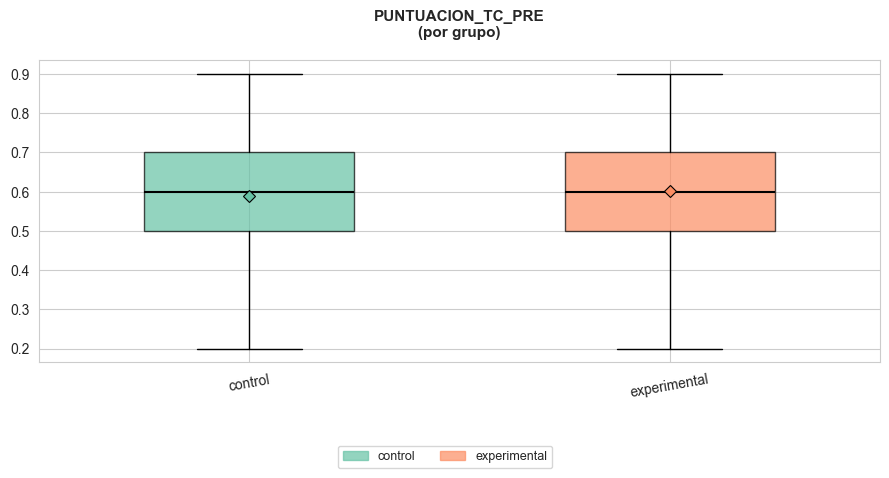

In [189]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ["puntuacion_tc_pre"]
    ],
    group_by='grupo',
    showfliers=True,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

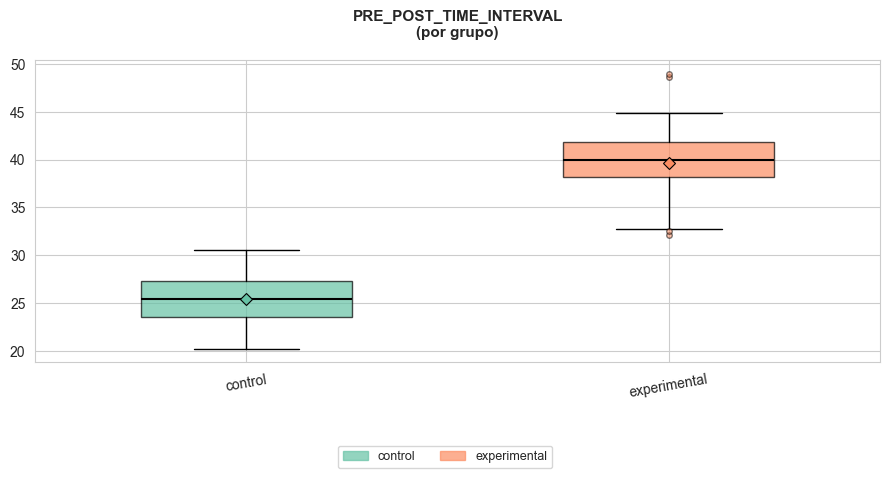

In [190]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ["pre_post_time_interval"]
    ],
    group_by='grupo',
    showfliers=True,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

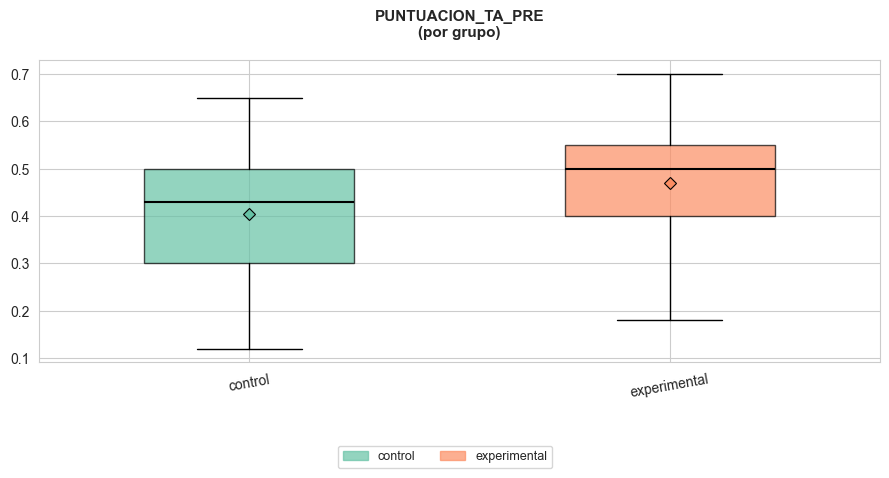

In [191]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ["puntuacion_ta_pre"]
    ],
    group_by='grupo',
    showfliers=True,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

## Experiment Results

### Experimental group

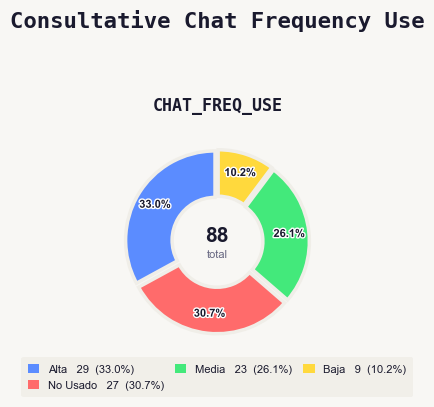

In [192]:
plot_quant_pie(
    df=forms_interactions_df,
    columns=['chat_freq_use'],
    title='Consultative Chat Frequency Use',
    figsize=(9, 4)
)

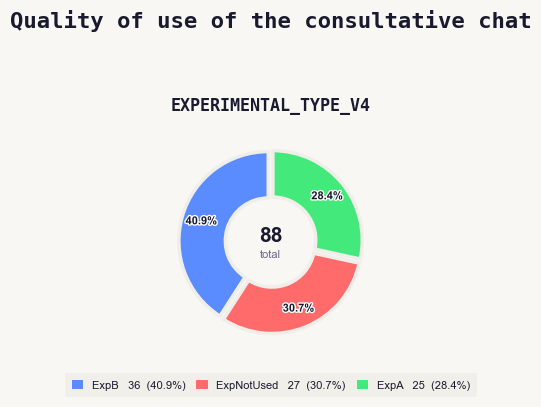

In [193]:
plot_quant_pie(
    df=forms_interactions_df,
    columns=['experimental_type_v4'],
    title='Quality of use of the consultative chat',
    figsize=(9, 4)
)

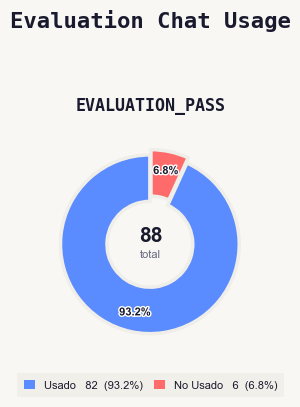

In [194]:
chat_evaluador = forms_interactions_df.filter(
    pl.col("grupo") == "experimental",
).with_columns(
    evaluation_pass = pl.when(
        pl.col("evaluation_pass").is_null()
    ).then(pl.lit("No Usado")
    ).otherwise(pl.lit("Usado")
    )
)

plot_quant_pie(
    df=chat_evaluador,
    columns=['evaluation_pass'],
    title='Evaluation Chat Usage',
    figsize=(9, 4)
)

### Knowledge

#### Pre-Post Comparison

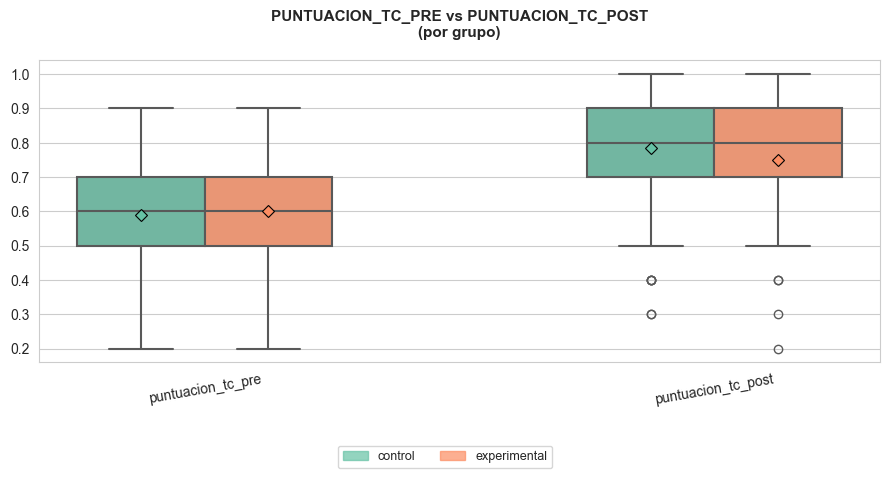

In [195]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ["puntuacion_tc_pre", "puntuacion_tc_post"]
    ],
    group_by='grupo',
    showfliers=True,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

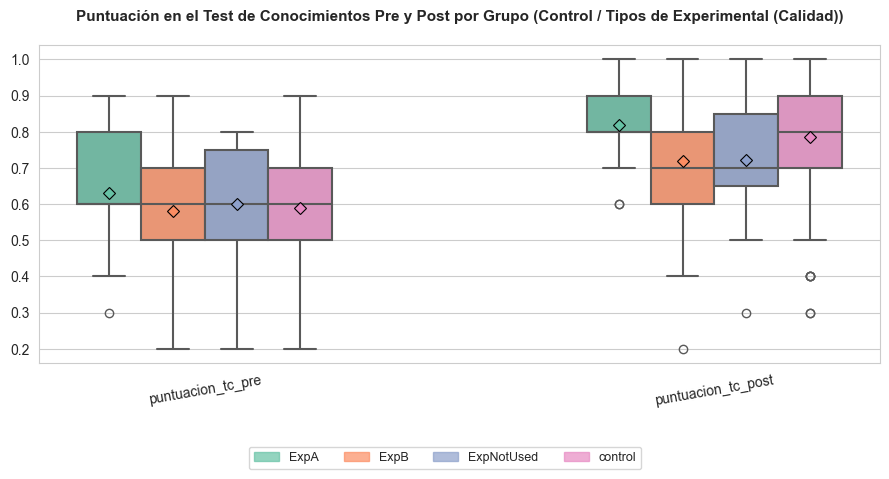

In [196]:
plot_quant_comparison(
    figsize=(9, 4),
    df=forms_interactions_df,
    comparisons=[
        ["puntuacion_tc_pre", "puntuacion_tc_post"]
    ],
    group_by='grupo_segmented_v4',
    showfliers=True,
    title="Puntuación en el Test de Conocimientos Pre y Post por Grupo (Control / Tipos de Experimental (Calidad))",
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

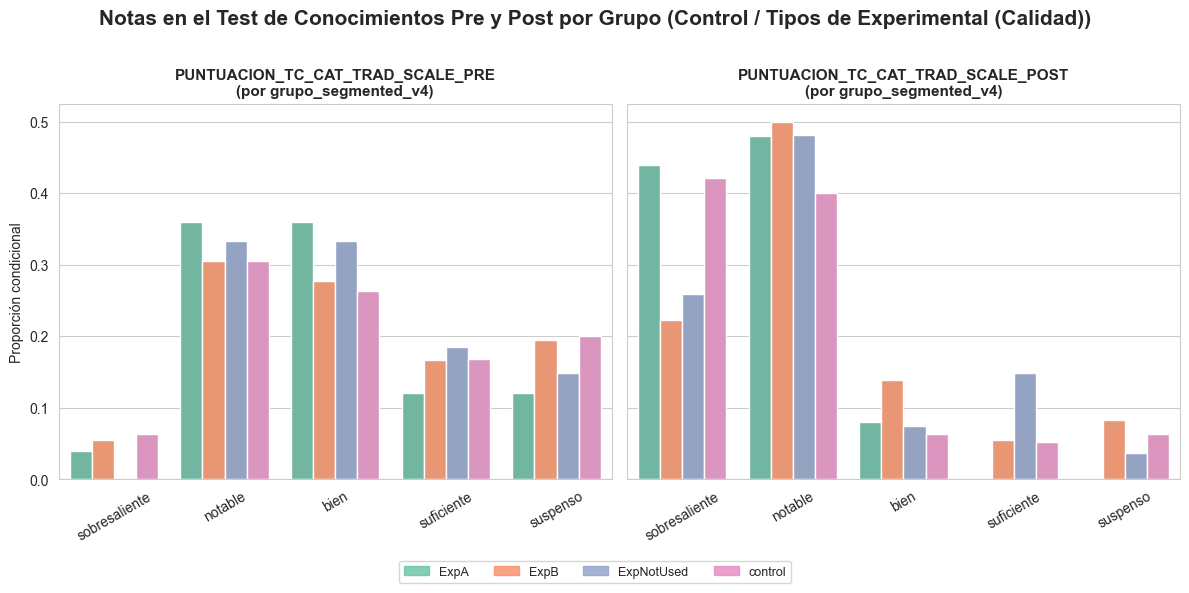

In [197]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['puntuacion_tc_cat_trad_scale_pre'], ['puntuacion_tc_cat_trad_scale_post'],
    ], 
    title="Notas en el Test de Conocimientos Pre y Post por Grupo (Control / Tipos de Experimental (Calidad))",
    bbox_to_anchor=(0.5,-0.14),
    group_by='grupo_segmented_v4',
    sharey=True,
    order=['sobresaliente', 'notable', 'bien', 'suficiente', 'suspenso']
)

#### Hake Gain

In [209]:
no_efecto_techo_df = forms_interactions_df.filter(~ pl.col('id').is_in(problematic_ids)).filter(
    pl.col("puntuacion_tc_pre") < 0.8	
)

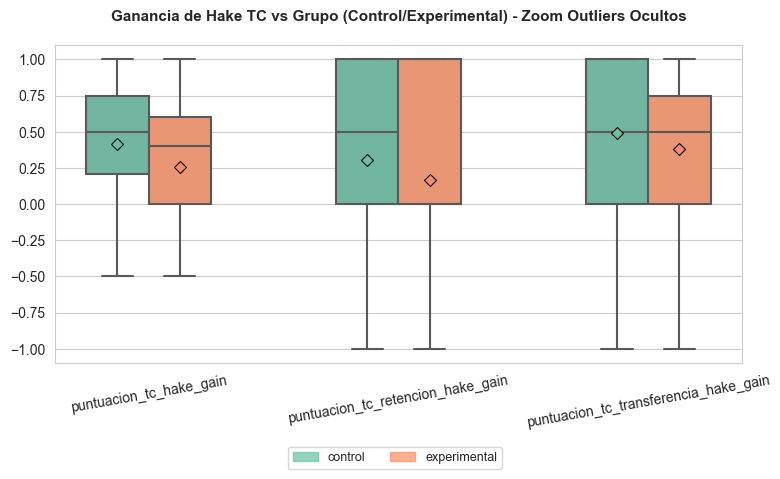

In [210]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        hake_gain_quant_cols
    ],
    group_by='grupo',
    showfliers=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    title='Ganancia de Hake TC vs Grupo (Control/Experimental) - Zoom Outliers Ocultos',
    figsize=(8,4)
)

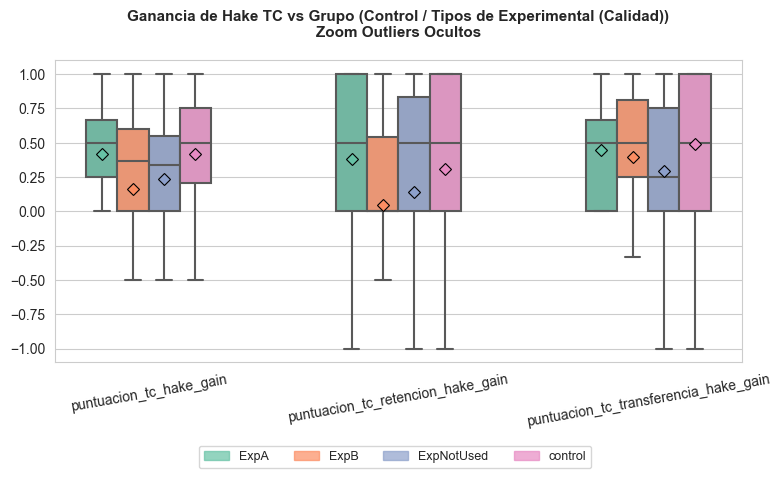

In [211]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        hake_gain_quant_cols
    ],
    group_by='grupo_segmented_v4',
    showfliers=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    title='Ganancia de Hake TC vs Grupo (Control / Tipos de Experimental (Calidad))\nZoom Outliers Ocultos',
    figsize=(8,4)
)

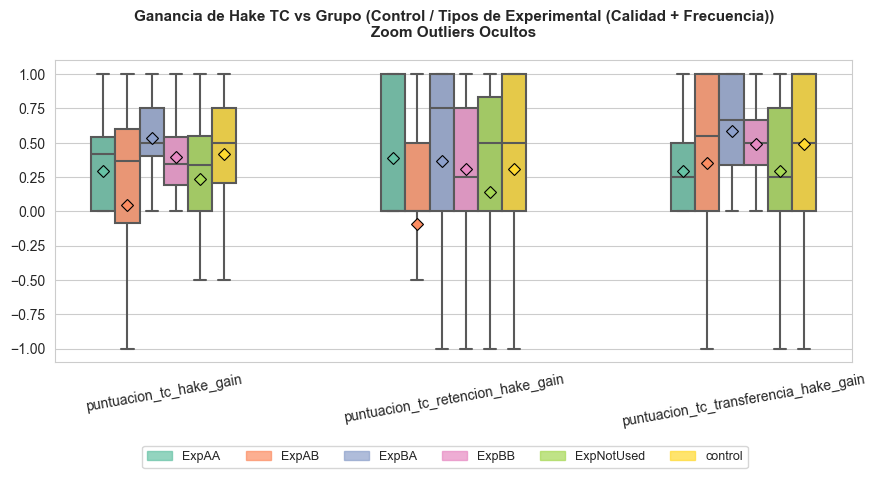

In [212]:
plot_quant_comparison(
    figsize = (9,4),
    df = forms_interactions_df.filter(~ pl.col('id').is_in(problematic_ids)),
    comparisons = [
        hake_gain_quant_cols
    ],
    group_by='grupo_segmented_v3',
    showfliers=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    title='Ganancia de Hake TC vs Grupo (Control / Tipos de Experimental (Calidad + Frecuencia))\nZoom Outliers Ocultos',
)

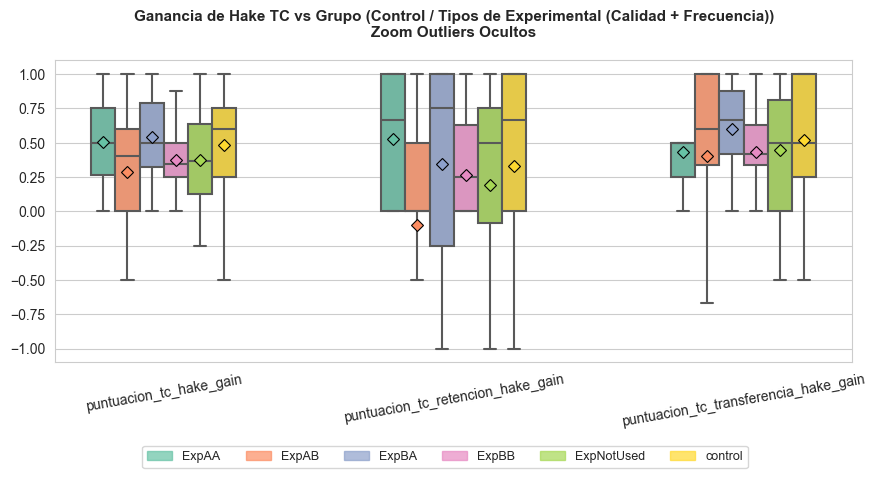

In [213]:
plot_quant_comparison(
    figsize = (9,4),
    df = no_efecto_techo_df,
    comparisons = [
        hake_gain_quant_cols
    ],
    group_by='grupo_segmented_v3',
    showfliers=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2),
    title='Ganancia de Hake TC vs Grupo (Control / Tipos de Experimental (Calidad + Frecuencia))\nZoom Outliers Ocultos',
)

#### Mejora

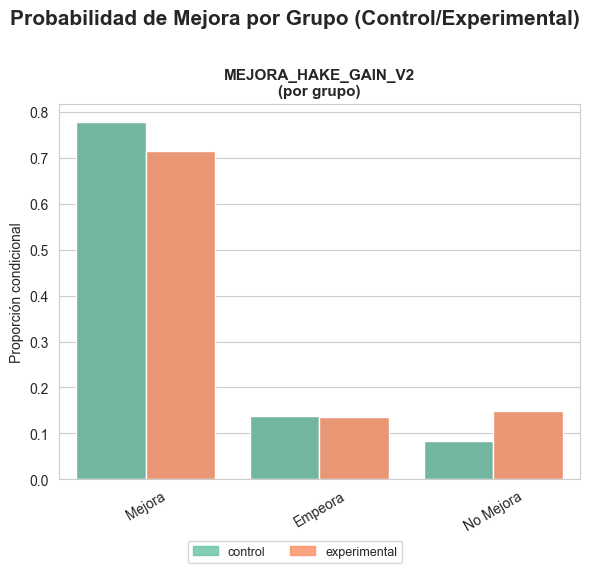

In [214]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['mejora_hake_gain_v2'],
    ], 
    title="Probabilidad de Mejora por Grupo (Control/Experimental)",
    bbox_to_anchor=(0.5,-0.1),
    group_by='grupo',
)

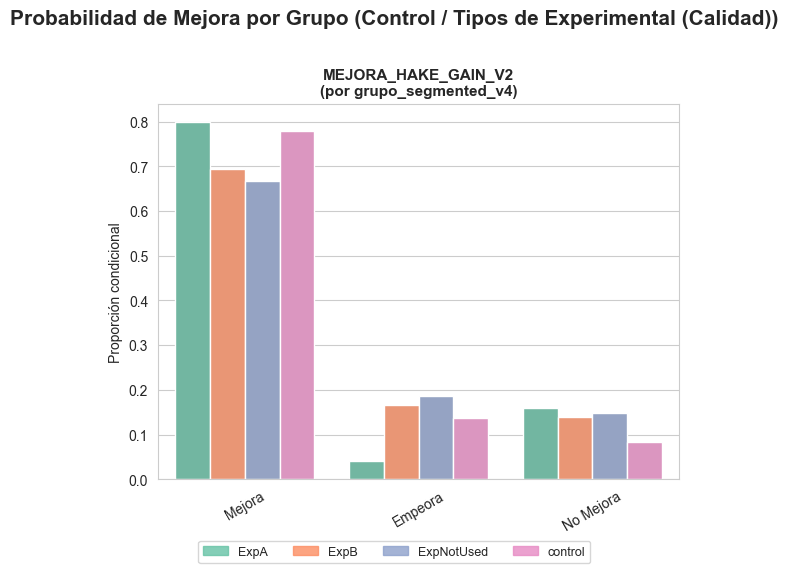

In [216]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['mejora_hake_gain_v2'],
    ], 
    title="Probabilidad de Mejora por Grupo (Control / Tipos de Experimental (Calidad))",
    bbox_to_anchor=(0.5,-0.1),
    group_by='grupo_segmented_v4',
)


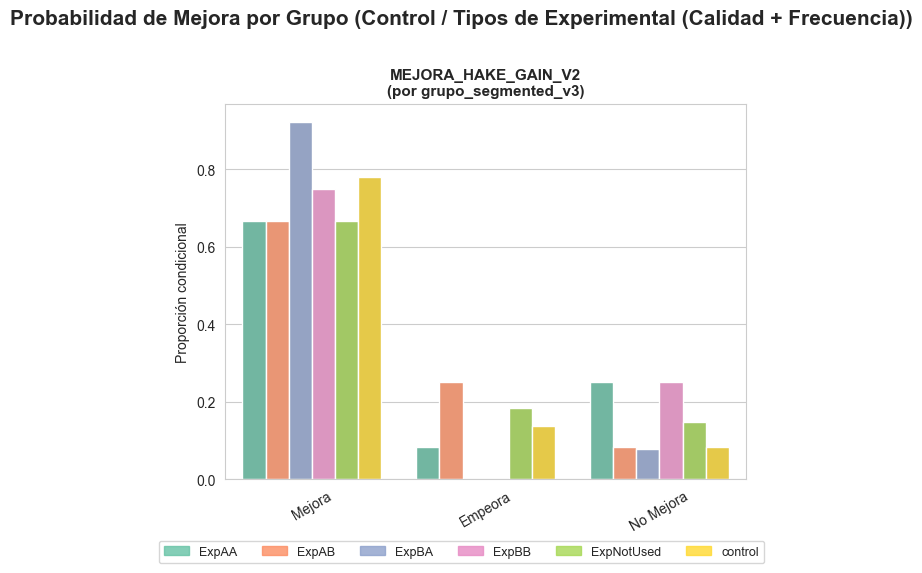

In [217]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['mejora_hake_gain_v2'],
    ], 
    title="Probabilidad de Mejora por Grupo (Control / Tipos de Experimental (Calidad + Frecuencia))",
    bbox_to_anchor=(0.5,-0.1),
    group_by='grupo_segmented_v3',
)

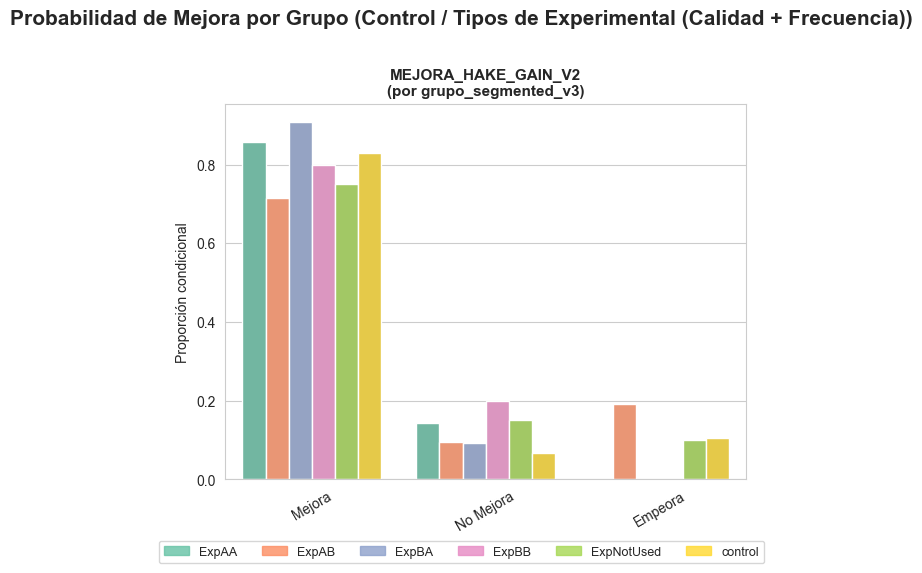

In [218]:
plot_cat_comparison(
    df=no_efecto_techo_df, 
    comparisons=[
        ['mejora_hake_gain_v2'],
    ], 
    title="Probabilidad de Mejora por Grupo (Control / Tipos de Experimental (Calidad + Frecuencia))",
    bbox_to_anchor=(0.5,-0.1),
    group_by='grupo_segmented_v3',
)
